# Bank Customer Transaction Analysis & High-Value Customer Prediction

### Objective
The objective of this project is to analyze bank transaction data to understand customer behavior, identify high-value customers, and build a machine learning model to predict potential high-value customers.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv("../data/bank_data.csv")

In [6]:
df.head()

,Customer_ID,Customer_Name,Transaction_Amount,Date,Transaction_Type,Age,CreditScore,SpendingScore,LoanHistory,Income
0,1005,Charles Solis,65280.80,17-10-2025,Debit,51,780,65,Average,68363
1,1018,Jesus Ware,33327.88,28-08-2025,Debit,27,521,41,Bad,106351
2,1053,Casey Dunn,18529.68,31-01-2026,Debit,18,632,32,Bad,112546
3,1042,Stephanie Costa,48797.31,29-03-2026,Credit,57,526,65,Bad,146130
4,1004,Barry Wolfe,43012.14,17-11-2025,Credit,39,379,4,Bad,57138


In [7]:
df.shape

(1000, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   int64  
 1   Customer_Name       1000 non-null   object 
 2   Transaction_Amount  1000 non-null   float64
 3   Date                1000 non-null   object 
 4   Transaction_Type    1000 non-null   object 
 5   Age                 1000 non-null   int64  
 6   CreditScore         1000 non-null   int64  
 7   SpendingScore       1000 non-null   int64  
 8   LoanHistory         1000 non-null   object 
 9   Income              1000 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 78.3+ KB


In [9]:
df.describe()

,Customer_ID,Transaction_Amount,Age,CreditScore,SpendingScore,Income
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1050.130000,50341.921960,40.600000,582.657000,52.956000,80903.720000
std,28.664067,28150.130344,13.932412,158.938091,29.128964,36988.728147
min,1001.000000,311.320000,18.000000,300.000000,1.000000,20034.000000
25%,1025.000000,28170.622500,28.000000,449.000000,26.000000,51591.000000
50%,1052.000000,49169.620000,40.000000,584.000000,55.000000,77450.000000
75%,1074.000000,74139.497500,52.250000,728.000000,78.000000,113394.000000
max,1100.000000,99963.820000,65.000000,850.000000,100.000000,149917.000000


In [10]:
df.isnull().sum()

Customer_ID           0
Customer_Name         0
Transaction_Amount    0
Date                  0
Transaction_Type      0
Age                   0
CreditScore           0
SpendingScore         0
LoanHistory           0
Income                0
dtype: int64

In [11]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [12]:
# Convert Date column to datetime

df['Date'] = pd.to_datetime(df['Date'])

C:\Users\dell\AppData\Local\Temp\ipykernel_20492\2765837458.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [13]:
df.dtypes

Customer_ID                    int64
Customer_Name                 object
Transaction_Amount           float64
Date                  datetime64[ns]
Transaction_Type              object
Age                            int64
CreditScore                    int64
SpendingScore                  int64
LoanHistory                   object
Income                         int64
dtype: object

In [14]:
df.head()

,Customer_ID,Customer_Name,Transaction_Amount,Date,Transaction_Type,Age,CreditScore,SpendingScore,LoanHistory,Income
0,1005,Charles Solis,65280.80,2025-10-17,Debit,51,780,65,Average,68363
1,1018,Jesus Ware,33327.88,2025-08-28,Debit,27,521,41,Bad,106351
2,1053,Casey Dunn,18529.68,2026-01-31,Debit,18,632,32,Bad,112546
3,1042,Stephanie Costa,48797.31,2026-03-29,Credit,57,526,65,Bad,146130
4,1004,Barry Wolfe,43012.14,2025-11-17,Credit,39,379,4,Bad,57138


In [15]:
# Extract the useful features from date

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [16]:
# Total transaction per customer

customer_summary = df.groupby('Customer_ID').agg({
    'Transaction_Amount': 'sum',
    'Customer_ID': 'count'
}).rename(columns={'Customer_ID': 'Transaction_Count'}).reset_index()

customer_summary.head()

,Customer_ID,Transaction_Amount,Transaction_Count
0,1001,620830.01,13
1,1002,216167.46,7
2,1003,376187.35,6
3,1004,619510.99,17
4,1005,364752.76,8


In [17]:
# Segment customers based on transaction amount

def segment_customer(amount):
    if amount > 50000:
        return "High"
    elif amount > 20000:
        return "Medium"
    else:
        return "Low"

df['Customer_Segment'] = df['Transaction_Amount'].apply(segment_customer)

In [18]:
df['HighValue'] = np.where(
    (df['Transaction_Amount'] > 50000) | (df['Income'] > 100000),
    1, 0
)

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['LoanHistory'] = le.fit_transform(df['LoanHistory'])
df['Transaction_Type'] = le.fit_transform(df['Transaction_Type'])

In [20]:
# Create income category

def income_group(income):
    if income > 100000:
        return "High Income"
    elif income > 50000:
        return "Medium Income"
    else:
        return "Low Income"

df['Income_Group'] = df['Income'].apply(income_group)

In [21]:
df.head()

,Customer_ID,Customer_Name,Transaction_Amount,Date,Transaction_Type,Age,CreditScore,SpendingScore,LoanHistory,Income,Year,Month,Day,Customer_Segment,HighValue,Income_Group
0,1005,Charles Solis,65280.80,2025-10-17,1,51,780,65,0,68363,2025,10,17,High,1,Medium Income
1,1018,Jesus Ware,33327.88,2025-08-28,1,27,521,41,1,106351,2025,8,28,Medium,1,High Income
2,1053,Casey Dunn,18529.68,2026-01-31,1,18,632,32,1,112546,2026,1,31,Low,1,High Income
3,1042,Stephanie Costa,48797.31,2026-03-29,0,57,526,65,1,146130,2026,3,29,Medium,1,High Income
4,1004,Barry Wolfe,43012.14,2025-11-17,0,39,379,4,1,57138,2025,11,17,Medium,0,Medium Income


In [22]:
# Count transactions per customer

transaction_freq = df.groupby('Customer_ID')['Transaction_Amount'].count()
df['Transaction_Frequency'] = df['Customer_ID'].map(transaction_freq)

In [23]:
# Count transactions per customer

avg_transaction = df.groupby('Customer_ID')['Transaction_Amount'].mean()
df['Avg_Transaction'] = df['Customer_ID'].map(avg_transaction)

In [24]:
df.head()

,Customer_ID,Customer_Name,Transaction_Amount,Date,Transaction_Type,Age,CreditScore,SpendingScore,LoanHistory,Income,Year,Month,Day,Customer_Segment,HighValue,Income_Group,Transaction_Frequency,Avg_Transaction
0,1005,Charles Solis,65280.80,2025-10-17,1,51,780,65,0,68363,2025,10,17,High,1,Medium Income,8,45594.095000
1,1018,Jesus Ware,33327.88,2025-08-28,1,27,521,41,1,106351,2025,8,28,Medium,1,High Income,7,50840.141429
2,1053,Casey Dunn,18529.68,2026-01-31,1,18,632,32,1,112546,2026,1,31,Low,1,High Income,18,41566.153889
3,1042,Stephanie Costa,48797.31,2026-03-29,0,57,526,65,1,146130,2026,3,29,Medium,1,High Income,6,23773.923333
4,1004,Barry Wolfe,43012.14,2025-11-17,0,39,379,4,1,57138,2025,11,17,Medium,0,Medium Income,17,36441.822941


EDA

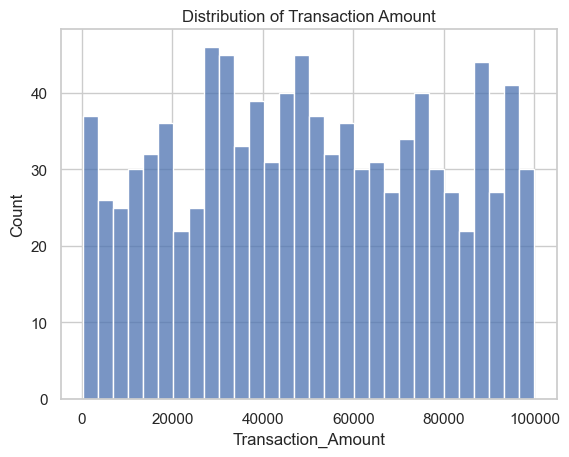

In [25]:
sns.histplot(df['Transaction_Amount'],bins = 30)
plt.title("Distribution of Transaction Amount") # most transactions are large or small 
plt.show()

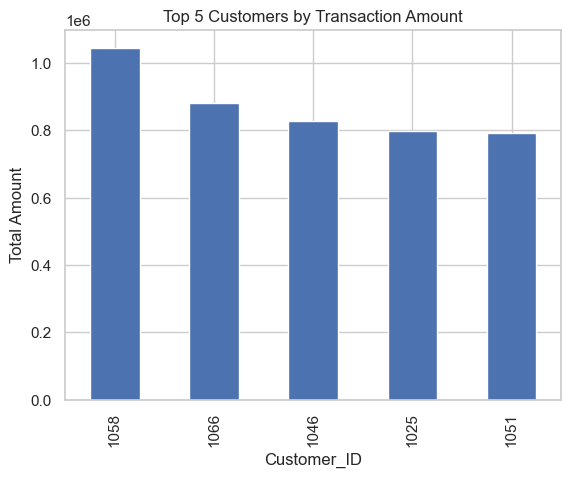

In [26]:
top5 = df.groupby('Customer_ID')['Transaction_Amount'].sum().sort_values(ascending=False).head(5)

top5.plot(kind='bar')
plt.title("Top 5 Customers by Transaction Amount")
plt.ylabel("Total Amount")
plt.show()

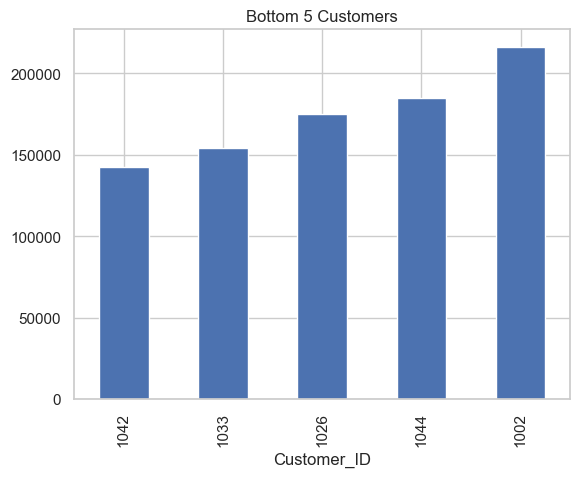

In [27]:
bottom5 = df.groupby('Customer_ID')['Transaction_Amount'].sum().sort_values().head(5)

bottom5.plot(kind='bar')
plt.title("Bottom 5 Customers")
plt.show()

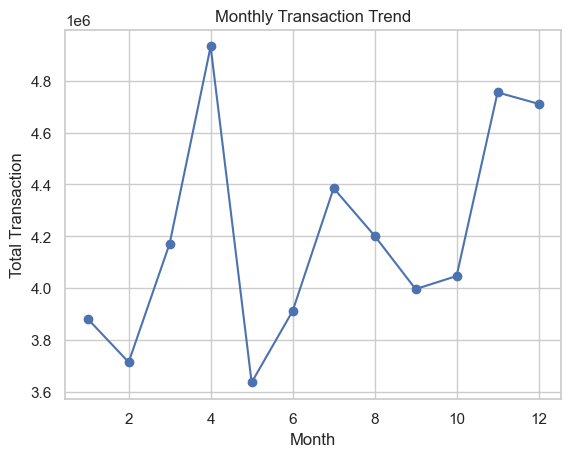

In [28]:
monthly = df.groupby('Month')['Transaction_Amount'].sum()

monthly.plot(marker='o')
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Total Transaction")
plt.show()

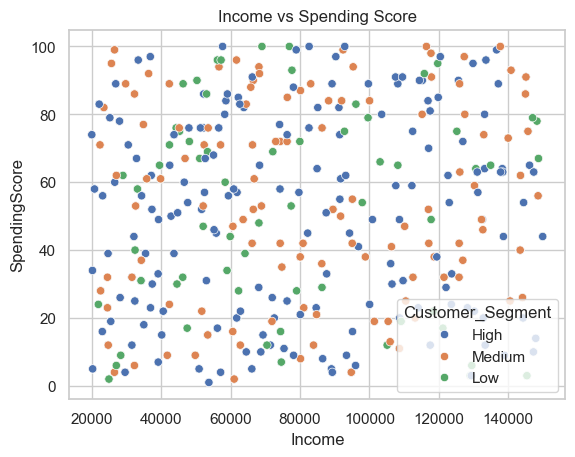

In [29]:
sns.scatterplot(x='Income', y='SpendingScore', hue='Customer_Segment', data=df)
plt.title("Income vs Spending Score")
plt.show()

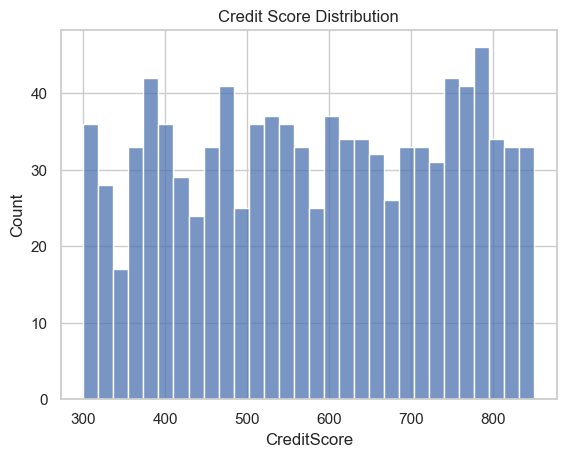

In [30]:
sns.histplot(df['CreditScore'], bins=30)
plt.title("Credit Score Distribution")
plt.show()

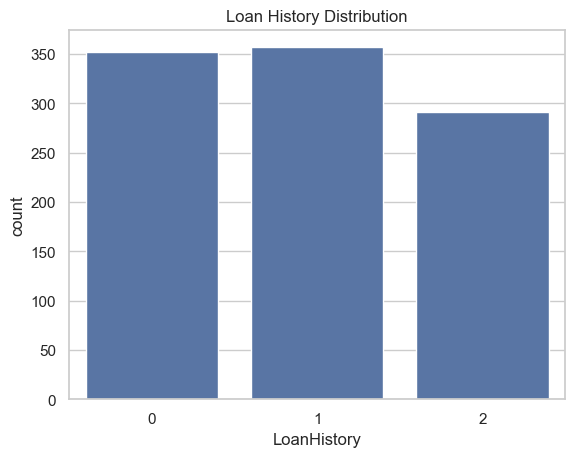

In [31]:
sns.countplot(x='LoanHistory', data=df)
plt.title("Loan History Distribution")
plt.show()

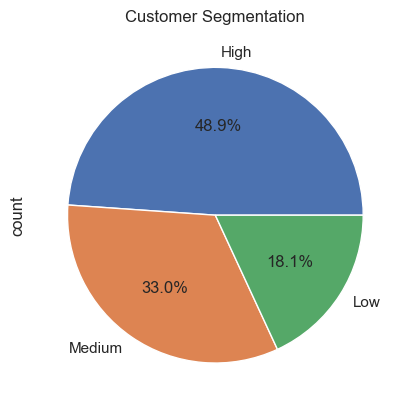

In [32]:
df['Customer_Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Segmentation")
plt.show()

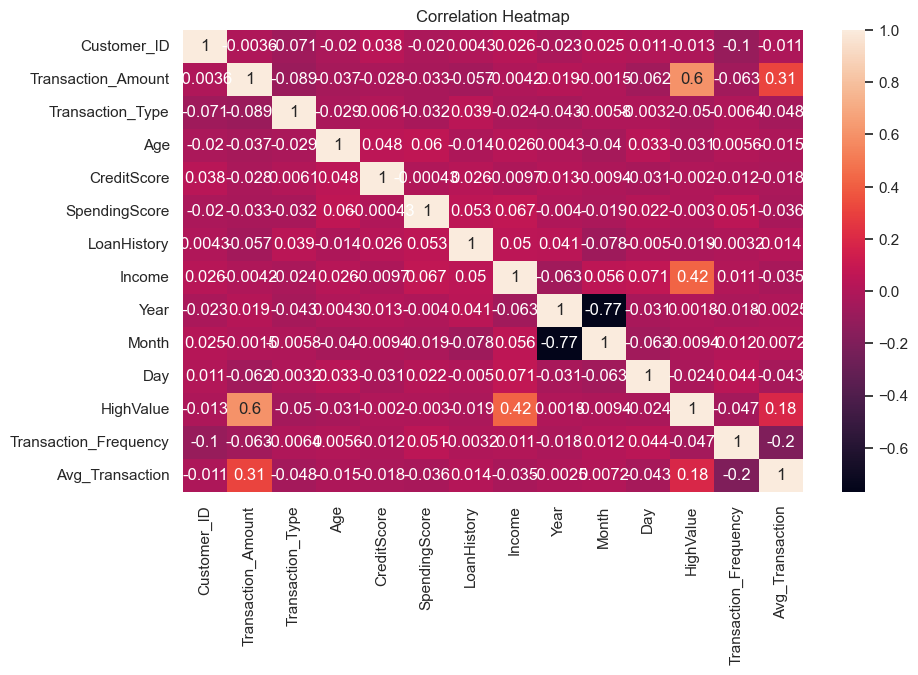

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

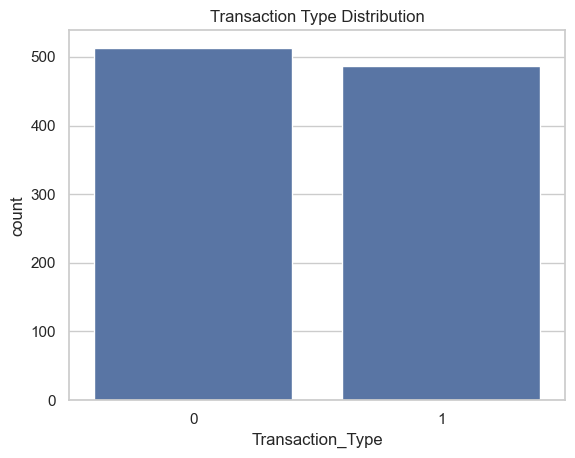

In [34]:
sns.countplot(x='Transaction_Type', data=df)
plt.title("Transaction Type Distribution")
plt.show()  # credit = 0, debit = 1

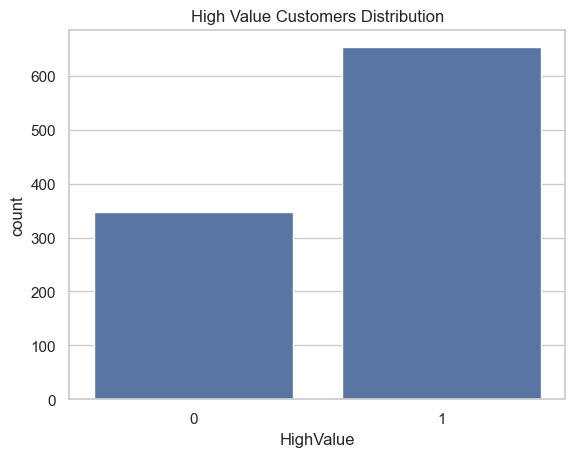

In [35]:
sns.countplot(x='HighValue', data=df)
plt.title("High Value Customers Distribution")
plt.show()

## 🤖 Machine Learning Model Building

In this section, we build a classification model to predict high-value customers based on customer features.

In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score
)


In [37]:
df['Total_Spending'] = df['Transaction_Frequency'] * df['Avg_Transaction']
df['HighValue'] = np.where(
    (df['Total_Spending'] > 50000) & (df['Income'] > 50000),
    1, 0
)

In [38]:
features = [
    'Age',
    'CreditScore',
    'SpendingScore',
    'Income',
    'LoanHistory',
    'Transaction_Frequency',
    'Avg_Transaction'
]

X = df[features]
y = df['HighValue']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT for class balance
)

In [40]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))  # increased iterations
])

param_grid_lr = {
    'model__C': [0.1, 1, 10],
    'model__solver': ['lbfgs']  # safe solver
}

grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    error_score='raise'   # 🔥 shows real error clearly
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

In [41]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

In [42]:
y_pred_lr = best_lr.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [43]:
def evaluate_model(name, y_true, y_pred, model=None, X_test=None):
    print(f"\n🔹 {name} Performance")
    print("-" * 30)
    
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    
    if model and X_test is not None:
        try:
            y_prob = model.predict_proba(X_test)[:, 1]
            print("ROC AUC  :", roc_auc_score(y_true, y_prob))
        except:
            pass
    
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

In [44]:
evaluate_model("Logistic Regression", y_test, y_pred_lr, best_lr, X_test)
evaluate_model("Random Forest", y_test, y_pred_rf, best_rf, X_test)


🔹 Logistic Regression Performance
------------------------------
Accuracy : 0.995
Precision: 0.9934640522875817
Recall   : 1.0
F1 Score : 0.9967213114754099
ROC AUC  : 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        48
           1       0.99      1.00      1.00       152

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

Confusion Matrix:
 [[ 47   1]
 [  0 152]]

🔹 Random Forest Performance
------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00       152

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
w

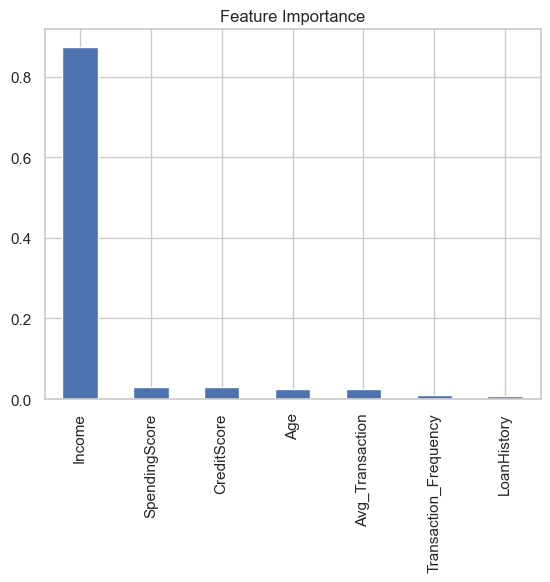

In [45]:
import matplotlib.pyplot as plt

importance = pd.Series(best_rf.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [46]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for train_idx, val_idx in cv.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    best_rf.fit(X_tr, y_tr)
    pred = best_rf.predict(X_val)
    
    cv_scores.append(f1_score(y_val, pred))

print("Final CV F1 Score:", np.mean(cv_scores))

Final CV F1 Score: 1.0


In [47]:
import joblib

joblib.dump(best_rf, "final_bank_model.pkl")

['final_bank_model.pkl']

In [48]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [49]:
import json

features = [
    'Age',
    'CreditScore',
    'SpendingScore',
    'Income',
    'LoanHistory',
    'Transaction_Frequency',
    'Avg_Transaction'
]

with open("../model/features.json", "w") as f:
    json.dump(features, f)